In [1]:
# Cell 1 — Install & Imports
import os
import shutil
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.utils import make_grid, save_image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

Device: cuda
GPU: Tesla T4


In [3]:
# Cell 2 — Load Metadata & Map Image Paths
base_dir = '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000'
csv_path = os.path.join(base_dir, 'HAM10000_metadata.csv')

df = pd.read_csv(csv_path)

# Map every image_id → absolute file path
image_paths = {}
for part in ['HAM10000_images_part_1', 'HAM10000_images_part_2']:
    folder = os.path.join(base_dir, part)
    if os.path.exists(folder):
        for fname in os.listdir(folder):
            if fname.endswith('.jpg'):
                img_id = os.path.splitext(fname)[0]
                image_paths[img_id] = os.path.join(folder, fname)

df['path'] = df['image_id'].map(image_paths)

lesion_type_dict = {
    'nv'   : 'Melanocytic nevi',
    'mel'  : 'Melanoma',
    'bkl'  : 'Benign keratosis',
    'bcc'  : 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc' : 'Vascular lesions',
    'df'   : 'Dermatofibroma'
}
df['cell_type'] = df['dx'].map(lesion_type_dict)
df['age'].fillna(df['age'].mean(), inplace=True)

print(f"Total records: {len(df)}")
print(df['dx'].value_counts())

Total records: 10015
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


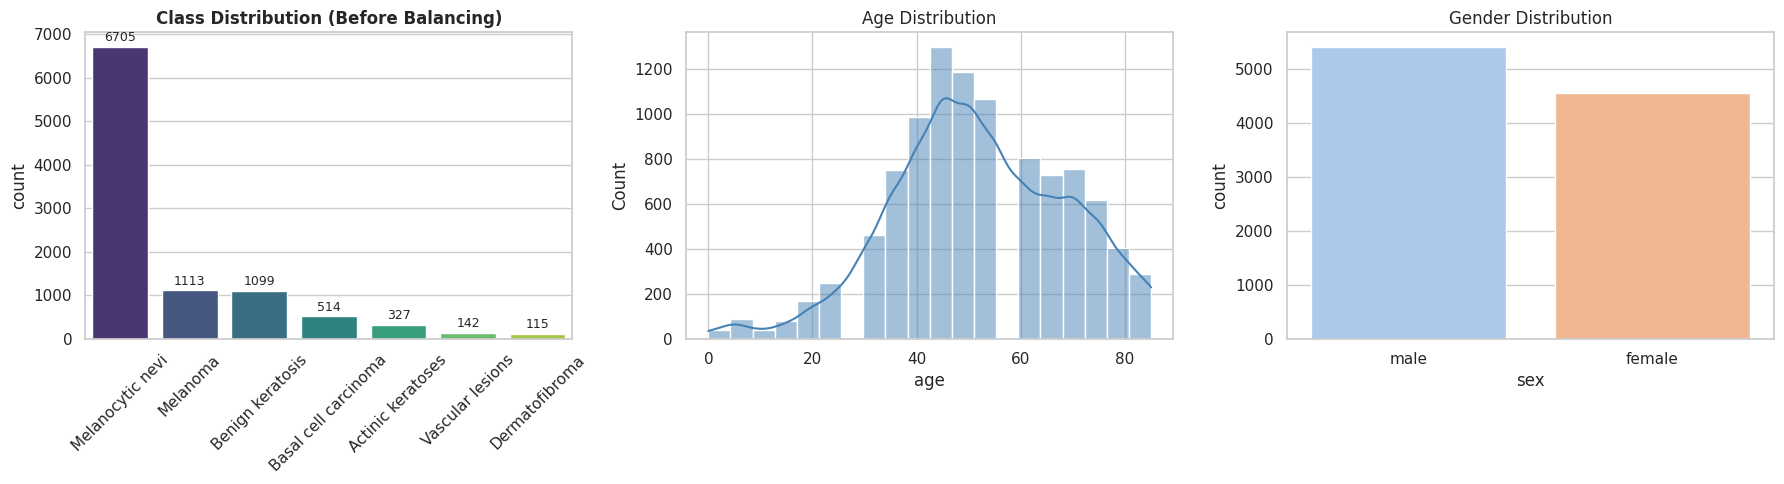

In [4]:
# Cell 3 — EDA: Class Distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Class counts
ax = sns.countplot(
    data=df, x='cell_type',
    order=df['cell_type'].value_counts().index,
    palette='viridis', ax=axes[0]
)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=9,
                xytext=(0, 4), textcoords='offset points')
axes[0].set_title('Class Distribution (Before Balancing)', fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

# Age distribution
sns.histplot(df['age'], bins=20, kde=True, ax=axes[1], color='steelblue')
axes[1].set_title('Age Distribution')

# Sex distribution
sex_data = df[df['sex'] != 'unknown']
sns.countplot(data=sex_data, x='sex', ax=axes[2], palette='pastel')
axes[2].set_title('Gender Distribution')

plt.tight_layout()
plt.show()

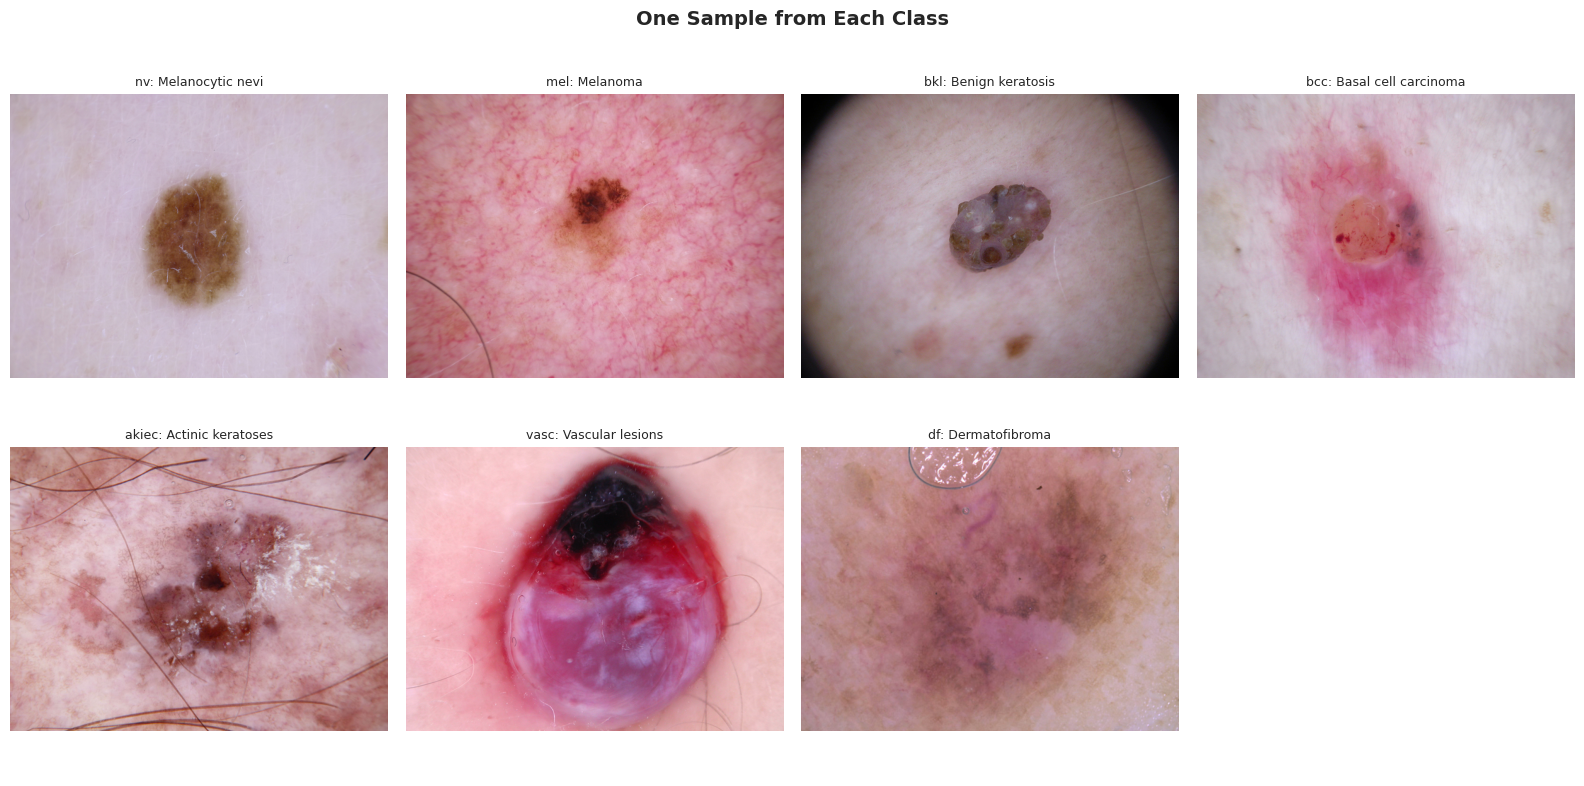

In [5]:
# Cell 4 — EDA: Sample Images Per Class
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, (code, name) in enumerate(lesion_type_dict.items()):
    sample_path = df[df['dx'] == code]['path'].dropna().sample(1).values[0]
    img = Image.open(sample_path)
    axes[i].imshow(img)
    axes[i].set_title(f"{code}: {name}", fontsize=9)
    axes[i].axis('off')

axes[7].axis('off')
plt.suptitle('One Sample from Each Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
# Cell 5 — Remove Duplicate Lesions & Train/Val Split
df_unique = df.drop_duplicates(subset='lesion_id').reset_index(drop=True)
print("After dedup:", df_unique['dx'].value_counts())

LABEL_MAP = {'nv': 0, 'mel': 1, 'bkl': 2, 'bcc': 3, 'akiec': 4, 'vasc': 5, 'df': 6}
INV_LABEL_MAP = {v: k for k, v in LABEL_MAP.items()}

train_df, val_df = train_test_split(
    df_unique, test_size=0.2, stratify=df_unique['dx'], random_state=42
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f"\nTrain: {len(train_df)} | Val: {len(val_df)}")
print("Train class counts:\n", train_df['dx'].value_counts())

# Target = largest class in train split
TARGET_COUNT = train_df['dx'].value_counts().max()
print(f"\nTarget samples per class: {TARGET_COUNT}")

After dedup: dx
nv       5403
bkl       727
mel       614
bcc       327
akiec     228
vasc       98
df         73
Name: count, dtype: int64

Train: 5976 | Val: 1494
Train class counts:
 dx
nv       4323
bkl       582
mel       491
bcc       262
akiec     182
vasc       78
df         58
Name: count, dtype: int64

Target samples per class: 4323


In [7]:
minority_classes = [cls for cls in LABEL_MAP
                    if cls != 'nv']     

In [ ]:
# Cell 6 — Prepare Minority-Class Folders for AC-GAN

GAN_DATA_ROOT = '/kaggle/working/acgan_data'

# Clean old GAN data to avoid mixing previous runs
if os.path.exists(GAN_DATA_ROOT):
    shutil.rmtree(GAN_DATA_ROOT)
os.makedirs(GAN_DATA_ROOT, exist_ok=True)

# AC-GAN will generate only minority classes.
# nv is majority, so we do not train GAN for nv.
minority_classes = [cls for cls in LABEL_MAP.keys() if cls != 'nv']

print("Minority classes for AC-GAN:", minority_classes)

for cls in minority_classes:
    cls_dir = os.path.join(GAN_DATA_ROOT, cls)
    os.makedirs(cls_dir, exist_ok=True)

    cls_df = train_df[train_df['dx'] == cls]

    copied = 0
    for _, row in cls_df.iterrows():
        src = row['path']
        if pd.notna(src) and os.path.exists(src):
            dst = os.path.join(cls_dir, os.path.basename(src))
            shutil.copy(src, dst)
            copied += 1

    print(f"{cls:6s}: {copied} images copied to {cls_dir}")

print("\nGAN training class counts:")
for cls in minority_classes:
    print(f"{cls:6s}: {len(os.listdir(os.path.join(GAN_DATA_ROOT, cls)))}")

In [ ]:
# Cell 7 — AC-GAN Architecture
# One conditional GAN for all minority classes.

import torch
import torch.nn as nn
from torchvision.utils import make_grid

Z_DIM = 128
IMG_SIZE = 64
CHANNELS = 3

GAN_CLASSES = minority_classes
GAN_N_CLASSES = len(GAN_CLASSES)

GAN_CLASS_TO_LABEL = {cls: i for i, cls in enumerate(GAN_CLASSES)}
GAN_LABEL_TO_CLASS = {i: cls for cls, i in GAN_CLASS_TO_LABEL.items()}

print("AC-GAN class mapping:")
print(GAN_CLASS_TO_LABEL)


def weights_init(m):
    classname = m.__class__.__name__

    if 'Conv' in classname or 'Linear' in classname:
        if hasattr(m, 'weight') and m.weight is not None:
            nn.init.normal_(m.weight.data, 0.0, 0.02)
        if hasattr(m, 'bias') and m.bias is not None:
            nn.init.constant_(m.bias.data, 0)

    elif 'BatchNorm' in classname:
        if hasattr(m, 'weight') and m.weight is not None:
            nn.init.normal_(m.weight.data, 1.0, 0.02)
        if hasattr(m, 'bias') and m.bias is not None:
            nn.init.constant_(m.bias.data, 0)


class ACGANGenerator(nn.Module):
    """
    Conditional generator:
    noise + class label -> 64x64 RGB image
    """

    def __init__(self, z_dim=Z_DIM, n_classes=GAN_N_CLASSES, channels=CHANNELS, feat=64):
        super().__init__()

        self.z_dim = z_dim
        self.label_emb = nn.Embedding(n_classes, z_dim)

        self.net = nn.Sequential(
            # [B, Z_DIM, 1, 1] -> [B, 512, 4, 4]
            nn.ConvTranspose2d(z_dim, feat * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(feat * 8),
            nn.ReLU(True),

            # 4 -> 8
            nn.ConvTranspose2d(feat * 8, feat * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feat * 4),
            nn.ReLU(True),

            # 8 -> 16
            nn.ConvTranspose2d(feat * 4, feat * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feat * 2),
            nn.ReLU(True),

            # 16 -> 32
            nn.ConvTranspose2d(feat * 2, feat, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feat),
            nn.ReLU(True),

            # 32 -> 64
            nn.ConvTranspose2d(feat, channels, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, noise, labels):
        """
        noise:  [B, Z_DIM]
        labels: [B]
        """
        label_embedding = self.label_emb(labels)
        conditioned_noise = noise * label_embedding
        conditioned_noise = conditioned_noise.view(conditioned_noise.size(0), self.z_dim, 1, 1)
        img = self.net(conditioned_noise)
        return img


class ACGANDiscriminator(nn.Module):
    """
    AC-GAN discriminator:
    image -> real/fake logit + class logits

    Important:
    - No Sigmoid before BCEWithLogitsLoss.
    - No Softmax before CrossEntropyLoss.
    """

    def __init__(self, n_classes=GAN_N_CLASSES, channels=CHANNELS, feat=64):
        super().__init__()

        self.features = nn.Sequential(
            # 64 -> 32
            nn.Conv2d(channels, feat, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # 32 -> 16
            nn.Conv2d(feat, feat * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feat * 2),
            nn.LeakyReLU(0.2, inplace=True),

            # 16 -> 8
            nn.Conv2d(feat * 2, feat * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feat * 4),
            nn.LeakyReLU(0.2, inplace=True),

            # 8 -> 4
            nn.Conv2d(feat * 4, feat * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feat * 8),
            nn.LeakyReLU(0.2, inplace=True)
        )

        self.adv_head = nn.Conv2d(feat * 8, 1, 4, 1, 0, bias=False)
        self.cls_head = nn.Linear(feat * 8 * 4 * 4, n_classes)

    def forward(self, img):
        feat = self.features(img)

        validity_logit = self.adv_head(feat).view(-1)
        class_logits = self.cls_head(feat.view(feat.size(0), -1))

        return validity_logit, class_logits


# Sanity check
G_test = ACGANGenerator().to(device)
D_test = ACGANDiscriminator().to(device)

z_test = torch.randn(4, Z_DIM, device=device)
y_test = torch.tensor([0, 1, 2, 3], dtype=torch.long, device=device)

fake_test = G_test(z_test, y_test)
validity_test, class_test = D_test(fake_test)

print("Generator output:", fake_test.shape)
print("Discriminator validity output:", validity_test.shape)
print("Discriminator class output:", class_test.shape)

del G_test, D_test, z_test, y_test, fake_test, validity_test, class_test
torch.cuda.empty_cache()

In [ ]:
# Cell 8 — Multi-Class Minority Dataset for AC-GAN

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from PIL import Image
from torchvision import transforms

gan_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.12,
        contrast=0.12,
        saturation=0.12,
        hue=0.03
    ),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])


class MinorityACGANDataset(Dataset):
    """
    Loads all minority-class real images for AC-GAN training.

    Returns:
        image tensor in [-1, 1]
        AC-GAN label from 0 to GAN_N_CLASSES-1
    """

    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []

        valid_ext = ('.jpg', '.jpeg', '.png')

        for cls in GAN_CLASSES:
            cls_dir = os.path.join(root_dir, cls)
            if not os.path.exists(cls_dir):
                continue

            label = GAN_CLASS_TO_LABEL[cls]

            for fname in os.listdir(cls_dir):
                if fname.lower().endswith(valid_ext):
                    self.samples.append((os.path.join(cls_dir, fname), label))

        if len(self.samples) == 0:
            raise RuntimeError(f"No images found in {root_dir}")

        self.labels = [label for _, label in self.samples]

        print(f"AC-GAN dataset size: {len(self.samples)}")
        counts = Counter(self.labels)
        for label_id in sorted(counts):
            print(f"  {GAN_LABEL_TO_CLASS[label_id]:6s}: {counts[label_id]}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]

        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)

        return img, torch.tensor(label, dtype=torch.long)

In [ ]:
# Cell 9 — AC-GAN Training Function

import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm


def denorm_gan_tensor(x):
    """
    Convert image tensor from [-1, 1] to [0, 1].
    """
    return (x * 0.5 + 0.5).clamp(0, 1)


def generated_stats(imgs):
    """
    imgs: tensor in [-1, 1], shape [B, 3, H, W]
    Returns mean and std in [0, 1] space.
    """
    imgs01 = denorm_gan_tensor(imgs.detach().cpu())
    mean_val = imgs01.mean().item()
    std_val = imgs01.std(dim=[1, 2, 3]).mean().item()
    return mean_val, std_val

def save_acgan_preview(G, epoch, sample_dir, n_per_class=4):
    """
    Saves a fixed preview grid with n_per_class samples per minority class.
    Works for integer epochs and for epoch='final'.
    """
    G.eval()

    labels = []
    for class_id in range(GAN_N_CLASSES):
        labels.extend([class_id] * n_per_class)

    labels = torch.tensor(labels, dtype=torch.long, device=device)
    noise = torch.randn(len(labels), Z_DIM, device=device)

    with torch.no_grad():
        fake_imgs = G(noise, labels).detach().cpu()

    mean_val, std_val = generated_stats(fake_imgs)

    fake_imgs = denorm_gan_tensor(fake_imgs)
    grid = make_grid(fake_imgs, nrow=n_per_class, padding=2)

    plt.figure(figsize=(n_per_class * 2.2, GAN_N_CLASSES * 2.0))
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.title(f"AC-GAN samples — epoch {epoch} | mean={mean_val:.3f}, std={std_val:.3f}")
    plt.axis("off")
    plt.tight_layout()

    if isinstance(epoch, int):
        filename = f"acgan_epoch_{epoch:04d}.png"
    else:
        filename = f"acgan_epoch_{str(epoch)}.png"

    save_path = os.path.join(sample_dir, filename)
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

    G.train()
    return mean_val, std_val


def train_acgan(
    root_dir,
    epochs=300,
    batch_size=64,
    lr=0.0002,
    lambda_cls=1.0,
    sample_every=25
):
    """
    Train one AC-GAN on all minority classes.

    Improvements over the GitHub-style notebook:
    - One conditional generator for all minority classes.
    - Weighted sampler so df/vasc appear more often during GAN training.
    - BCEWithLogitsLoss instead of Sigmoid + BCELoss.
    - CrossEntropyLoss uses raw class logits, not Softmax output.
    - Dynamic batch size; no hardcoded batch_size inside loop.
    - Saves final and periodic checkpoints instead of choosing only lowest G loss.
    """

    print(f"\n{'=' * 70}")
    print("Training AC-GAN on all minority classes")
    print(f"{'=' * 70}")

    dataset = MinorityACGANDataset(root_dir, transform=gan_transforms)

    # Balanced sampling across minority classes.
    # This is important because df and vasc are much smaller than mel/bkl.
    label_counts = Counter(dataset.labels)
    sample_weights = [1.0 / label_counts[label] for label in dataset.labels]

    samples_per_epoch = max(label_counts.values()) * GAN_N_CLASSES

    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=samples_per_epoch,
        replacement=True
    )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        sampler=sampler,
        num_workers=2,
        pin_memory=True,
        drop_last=False
    )

    print(f"\nBatches per epoch: {len(loader)}")
    print(f"Samples per epoch with balanced sampler: {samples_per_epoch}")
    print(f"Batch size: {batch_size}")
    print(f"Learning rate: {lr}")

    G = ACGANGenerator().to(device)
    D = ACGANDiscriminator().to(device)

    G.apply(weights_init)
    D.apply(weights_init)

    adv_loss = nn.BCEWithLogitsLoss()
    cls_loss = nn.CrossEntropyLoss()

    opt_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

    ckpt_dir = '/kaggle/working/acgan_ckpt'
    sample_dir = '/kaggle/working/acgan_samples'
    os.makedirs(ckpt_dir, exist_ok=True)
    os.makedirs(sample_dir, exist_ok=True)

    g_losses = []
    d_losses = []
    d_adv_losses = []
    d_cls_losses = []

    for epoch in range(1, epochs + 1):
        G.train()
        D.train()

        epoch_g = 0.0
        epoch_d = 0.0
        epoch_d_adv = 0.0
        epoch_d_cls = 0.0
        n_batches = 0

        pbar = tqdm(loader, desc=f"AC-GAN Epoch {epoch}/{epochs}", leave=False)

        for real_imgs, real_labels in pbar:
            real_imgs = real_imgs.to(device, non_blocking=True)
            real_labels = real_labels.to(device, non_blocking=True)

            bsz = real_imgs.size(0)
            if bsz < 2:
                continue

            # -----------------------------
            # Train Discriminator
            # -----------------------------
            opt_D.zero_grad(set_to_none=True)

            real_targets = torch.empty(bsz, device=device).uniform_(0.85, 1.00)
            fake_targets = torch.empty(bsz, device=device).uniform_(0.00, 0.15)

            real_validity, real_class_logits = D(real_imgs)

            d_real_adv = adv_loss(real_validity, real_targets)
            d_real_cls = cls_loss(real_class_logits, real_labels)

            z = torch.randn(bsz, Z_DIM, device=device)
            gen_labels = torch.randint(0, GAN_N_CLASSES, (bsz,), device=device)
            fake_imgs = G(z, gen_labels).detach()

            fake_validity, fake_class_logits = D(fake_imgs)

            d_fake_adv = adv_loss(fake_validity, fake_targets)
            d_fake_cls = cls_loss(fake_class_logits, gen_labels)

            d_adv = 0.5 * (d_real_adv + d_fake_adv)
            d_cls = 0.5 * (d_real_cls + d_fake_cls)

            d_loss = d_adv + lambda_cls * d_cls

            d_loss.backward()
            opt_D.step()

            # -----------------------------
            # Train Generator
            # -----------------------------
            opt_G.zero_grad(set_to_none=True)

            z = torch.randn(bsz, Z_DIM, device=device)
            gen_labels = torch.randint(0, GAN_N_CLASSES, (bsz,), device=device)

            fake_imgs = G(z, gen_labels)
            fake_validity, fake_class_logits = D(fake_imgs)

            valid_targets_for_G = torch.ones(bsz, device=device)

            g_adv = adv_loss(fake_validity, valid_targets_for_G)
            g_cls = cls_loss(fake_class_logits, gen_labels)

            g_loss = g_adv + lambda_cls * g_cls

            g_loss.backward()
            opt_G.step()

            epoch_g += g_loss.item()
            epoch_d += d_loss.item()
            epoch_d_adv += d_adv.item()
            epoch_d_cls += d_cls.item()
            n_batches += 1

            pbar.set_postfix({
                "D": f"{d_loss.item():.3f}",
                "G": f"{g_loss.item():.3f}"
            })

        epoch_g /= max(1, n_batches)
        epoch_d /= max(1, n_batches)
        epoch_d_adv /= max(1, n_batches)
        epoch_d_cls /= max(1, n_batches)

        g_losses.append(epoch_g)
        d_losses.append(epoch_d)
        d_adv_losses.append(epoch_d_adv)
        d_cls_losses.append(epoch_d_cls)

        if epoch % sample_every == 0 or epoch == 1:
            print(
                f"Epoch {epoch:4d}/{epochs} | "
                f"D_loss: {epoch_d:.4f} | "
                f"D_adv: {epoch_d_adv:.4f} | "
                f"D_cls: {epoch_d_cls:.4f} | "
                f"G_loss: {epoch_g:.4f}"
            )

            mean_val, std_val = save_acgan_preview(
                G,
                epoch=epoch,
                sample_dir=sample_dir,
                n_per_class=4
            )

            if std_val < 0.03:
                print(
                    "WARNING: Generated samples have very low pixel variance. "
                    "This may indicate gray-image collapse."
                )

        if epoch % 100 == 0:
            torch.save(G.state_dict(), os.path.join(ckpt_dir, f"acgan_G_epoch_{epoch}.pth"))
            torch.save(D.state_dict(), os.path.join(ckpt_dir, f"acgan_D_epoch_{epoch}.pth"))

    final_G_path = os.path.join(ckpt_dir, "acgan_G_final.pth")
    final_D_path = os.path.join(ckpt_dir, "acgan_D_final.pth")

    torch.save(G.state_dict(), final_G_path)
    torch.save(D.state_dict(), final_D_path)

    print(f"\nFinal generator saved to: {final_G_path}")
    print(f"Final discriminator saved to: {final_D_path}")

    plt.figure(figsize=(9, 4))
    plt.plot(g_losses, label="Generator loss")
    plt.plot(d_losses, label="Discriminator total loss")
    plt.plot(d_adv_losses, label="D adversarial loss", alpha=0.7)
    plt.plot(d_cls_losses, label="D class loss", alpha=0.7)
    plt.title("AC-GAN Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("\nFinal preview:")
    save_acgan_preview(G, epoch="final", sample_dir=sample_dir, n_per_class=4)

    G.eval()
    return G

In [ ]:
# Cell 10 — Train One AC-GAN for All Minority Classes

# Start with 300 epochs.
# If samples still look weak, increase to 500.
# If you only want a quick test, use 50 epochs first.

trained_acgan_generator = train_acgan(
    root_dir=GAN_DATA_ROOT,
    epochs=300,
    batch_size=64,
    lr=0.0002,
    lambda_cls=1.0,
    sample_every=25
)

print("\nAC-GAN training complete.")
print("Checkpoints saved to /kaggle/working/acgan_ckpt/")
print("Preview grids saved to /kaggle/working/acgan_samples/")

In [ ]:
# Cell 11 — Generate Synthetic Images with AC-GAN to Balance Dataset

SYN_ROOT = '/kaggle/working/synthetic'

# Clean old synthetic images from previous DCGAN runs
if os.path.exists(SYN_ROOT):
    shutil.rmtree(SYN_ROOT)
os.makedirs(SYN_ROOT, exist_ok=True)


def tensor_to_pil(t):
    """
    Convert one generated tensor from [-1, 1] to PIL image.
    """
    t = denorm_gan_tensor(t.detach().cpu())
    arr = (t.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    return Image.fromarray(arr)


def generate_synthetic_for_class(
    G,
    cls_name,
    n_needed,
    out_dir,
    batch_size=64,
    output_size=224
):
    """
    Generate n_needed synthetic images for one class using AC-GAN.
    """
    os.makedirs(out_dir, exist_ok=True)

    acgan_label = GAN_CLASS_TO_LABEL[cls_name]

    generated = 0
    std_values = []

    G.eval()

    with torch.no_grad():
        pbar = tqdm(total=n_needed, desc=f"Generating {cls_name}", leave=False)

        while generated < n_needed:
            n = min(batch_size, n_needed - generated)

            z = torch.randn(n, Z_DIM, device=device)
            labels = torch.full(
                (n,),
                acgan_label,
                dtype=torch.long,
                device=device
            )

            imgs = G(z, labels)

            _, batch_std = generated_stats(imgs)
            std_values.append(batch_std)

            for i, img_tensor in enumerate(imgs):
                pil_img = tensor_to_pil(img_tensor)
                pil_img = pil_img.resize((output_size, output_size), Image.BILINEAR)

                save_path = os.path.join(
                    out_dir,
                    f"{cls_name}_syn_{generated + i:05d}.jpg"
                )

                pil_img.save(save_path, quality=92)

            generated += n
            pbar.update(n)

        pbar.close()

    avg_std = float(np.mean(std_values)) if std_values else 0.0
    return generated, avg_std


syn_stats = {}

G = trained_acgan_generator
G.eval()

for cls in minority_classes:
    cls_real_count = len(train_df[train_df['dx'] == cls])
    n_needed = TARGET_COUNT - cls_real_count

    out_dir = os.path.join(SYN_ROOT, cls)

    print(f"\n[{cls}] Real: {cls_real_count} | Need synthetic: {n_needed}")

    generated, avg_std = generate_synthetic_for_class(
        G=G,
        cls_name=cls,
        n_needed=n_needed,
        out_dir=out_dir,
        batch_size=64,
        output_size=224
    )

    syn_stats[cls] = {
        "real": cls_real_count,
        "synthetic": generated,
        "total": cls_real_count + generated,
        "avg_generated_std": avg_std
    }

    print(
        f"  Done | synthetic: {generated} | "
        f"total after balancing: {cls_real_count + generated} | "
        f"avg std: {avg_std:.4f}"
    )

    if avg_std < 0.03:
        print(
            f"  WARNING: {cls} generated images may be collapsed or gray. "
            f"Inspect before using them for classifier training."
        )

print("\nSynthetic generation summary:")
syn_stats_df = pd.DataFrame(syn_stats).T
print(syn_stats_df.to_string())

In [ ]:
# Cell 12 — Visual Inspection of AC-GAN Synthetic Images

n_show = 8
fig, axes = plt.subplots(
    len(minority_classes),
    n_show,
    figsize=(2.2 * n_show, 2.4 * len(minority_classes))
)

if len(minority_classes) == 1:
    axes = np.expand_dims(axes, axis=0)

for row_idx, cls in enumerate(minority_classes):
    syn_dir = os.path.join(SYN_ROOT, cls)

    syn_files = [
        f for f in os.listdir(syn_dir)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    syn_files = syn_files[:n_show]

    for col_idx in range(n_show):
        ax = axes[row_idx, col_idx]
        ax.axis("off")

        if col_idx < len(syn_files):
            img = Image.open(os.path.join(syn_dir, syn_files[col_idx])).convert("RGB")
            ax.imshow(img)

        if col_idx == 0:
            ax.set_ylabel(cls, fontsize=12, fontweight="bold")

plt.suptitle("AC-GAN Synthetic Images — Visual Quality Check", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("Inspection checklist:")
print("1. Images should not be flat gray.")
print("2. Images within each class should look different from each other.")
print("3. df and vasc should be inspected most carefully.")
print("4. If a class looks collapsed, do not use those synthetic images for classifier training.")

In [8]:
SYN_ROOT = '/kaggle/input/datasets/umaraftab174/acgan-synthetic/synthetic'

In [9]:
# Cell 13 — Dataset Class with Real + Synthetic Images

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

IMG_DIRS = [
    os.path.join(base_dir, 'HAM10000_images_part_1'),
    os.path.join(base_dir, 'HAM10000_images_part_2')
]

class HAMDatasetBalanced(Dataset):
    """
    Loads real HAM10000 images from img_dirs and synthetic images from syn_root.
    For nv (majority class), loads only real images.
    For all minority classes, loads real + synthetic to reach TARGET_COUNT.
    """
    def __init__(self, real_df, img_dirs, syn_root, transform=None, is_train=True):
        self.transform = transform
        self.records = []   # list of (path, label)

        # Build image_id → path map from HAM10000 folders
        path_map = {}
        for d in img_dirs:
            if not os.path.exists(d):
                continue
            for f in os.listdir(d):
                if f.endswith('.jpg'):
                    path_map[f.replace('.jpg', '')] = os.path.join(d, f)

        # --- Real images ---
        for _, row in real_df.iterrows():
            p = path_map.get(row['image_id'])
            if p:
                self.records.append((p, LABEL_MAP[row['dx']]))

        # --- Synthetic images (minority classes only) ---
        if is_train and syn_root:
            for cls in minority_classes:
                syn_dir = os.path.join(syn_root, cls)
                if not os.path.exists(syn_dir):
                    continue
                for f in os.listdir(syn_dir):
                    if f.endswith('.jpg'):
                        self.records.append(
                            (os.path.join(syn_dir, f), LABEL_MAP[cls])
                        )

        # Shuffle records
        import random
        random.seed(42)
        random.shuffle(self.records)

        # Print balance check
        from collections import Counter
        label_counts = Counter(lbl for _, lbl in self.records)
        print(f"  Dataset size: {len(self.records)}")
        for lbl, cnt in sorted(label_counts.items()):
            print(f"    {INV_LABEL_MAP[lbl]:6s}: {cnt}")

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        path, label = self.records[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label

In [10]:
# Cell 14 — Build DataLoaders

print("Building training dataset (real + synthetic):")
train_dataset = HAMDatasetBalanced(
    real_df=train_df,
    img_dirs=IMG_DIRS,
    syn_root=SYN_ROOT,
    transform=train_transforms,
    is_train=True
)

print("\nBuilding validation dataset (real only):")
val_dataset = HAMDatasetBalanced(
    real_df=val_df,
    img_dirs=IMG_DIRS,
    syn_root=None,
    transform=val_transforms,
    is_train=False
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2
)

print(f"\nTrain batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Building training dataset (real + synthetic):
  Dataset size: 30261
    nv    : 4323
    mel   : 4323
    bkl   : 4323
    bcc   : 4323
    akiec : 4323
    vasc  : 4323
    df    : 4323

Building validation dataset (real only):
  Dataset size: 1494
    nv    : 1080
    mel   : 123
    bkl   : 145
    bcc   : 65
    akiec : 46
    vasc  : 20
    df    : 15

Train batches: 473 | Val batches: 24


In [12]:
# Cell 15 — Build ResNeXt101-64x4d Classifier

NUM_CLASSES = 7

# ResNeXt101 pretrained weights
weights = models.ResNeXt101_64X4D_Weights.IMAGENET1K_V1
model = models.resnext101_64x4d(weights=weights, progress=True)

# Unfreeze all layers — full fine-tuning
for param in model.parameters():
    param.requires_grad = True

# Check original final layer
print("Original final layer:")
print(model.fc)

# ResNeXt / ResNet uses model.fc, not model.classifier
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, NUM_CLASSES)

model = model.to(device)

if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model, device_ids=[0, 1])

# These weights must match your class index order:
# {'nv': 0, 'mel': 1, 'bkl': 2, 'bcc': 3, 'akiec': 4, 'vasc': 5, 'df': 6}
class_weights = torch.tensor([
    1.0,   # nv
    2.0,   # mel
    1.0,   # bkl
    1.2,   # bcc
    1.3,   # akiec
    1.5,   # vasc
    1.5    # df
], dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=30,
    eta_min=1e-6
)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("\nNew final layer:")
if isinstance(model, nn.DataParallel):
    print(model.module.fc)
else:
    print(model.fc)

print(f"\nTrainable parameters: {total_params:,}")

Original final layer:
Linear(in_features=2048, out_features=1000, bias=True)
Using 2 GPUs

New final layer:
Linear(in_features=2048, out_features=7, bias=True)

Trainable parameters: 81,420,615


In [13]:
# Cell 16 — Training & Validation Loop Functions

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for imgs, labels in tqdm(loader, desc='  Train', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), 100.0 * correct / total


def validate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc='  Val  ', leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    acc = 100.0 * correct / total
    bal_acc = balanced_accuracy_score(all_labels, all_preds) * 100.0
    return total_loss / len(loader), acc, bal_acc, all_preds, all_labels


class EarlyStopping:
    def __init__(self, patience=6, metric='balanced_acc'):
        self.patience = patience
        self.counter  = 0
        self.best     = -float('inf')
        self.metric   = metric

    def __call__(self, score):
        if score > self.best:
            self.best    = score
            self.counter = 0
            return False
        self.counter += 1
        print(f"  EarlyStopping counter: {self.counter}/{self.patience}")
        return self.counter >= self.patience

In [14]:
# Cell 17 — Run Training

EPOCHS    = 30
CKPT_PATH = '/kaggle/working/convnext_base_acgan_30_epochs.pth'

best_bal_acc = 0.0
early_stop   = EarlyStopping(patience=6)

history = {'train_loss': [], 'val_loss': [],
           'train_acc': [],  'val_acc': [], 'val_bal_acc': []}

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")

    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    vl_loss, vl_acc, vl_bal, preds, labels = validate(model, val_loader, criterion)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)
    history['val_bal_acc'].append(vl_bal)

    print(f"  Train  | Loss: {tr_loss:.4f}  Acc: {tr_acc:.2f}%")
    print(f"  Val    | Loss: {vl_loss:.4f}  Acc: {vl_acc:.2f}%  "
          f"Balanced Acc: {vl_bal:.2f}%  "
          f"LR: {scheduler.get_last_lr()[0]:.6f}")

    if vl_bal > best_bal_acc:
        best_bal_acc = vl_bal
        torch.save(model.state_dict(), CKPT_PATH)
        print(f"  ✅ Best model saved  (Balanced Acc: {vl_bal:.2f}%)")

    if early_stop(vl_bal):
        print("Early stopping triggered.")
        break

print(f"\nBest Balanced Accuracy: {best_bal_acc:.2f}%")


Epoch 1/30


  Train:   0%|          | 0/473 [00:00<?, ?it/s]

  Val  :   0%|          | 0/24 [00:00<?, ?it/s]

  Train  | Loss: 0.6526  Acc: 75.14%
  Val    | Loss: 0.5514  Acc: 81.33%  Balanced Acc: 59.01%  LR: 0.000100
  ✅ Best model saved  (Balanced Acc: 59.01%)

Epoch 2/30


  Train:   0%|          | 0/473 [00:00<?, ?it/s]

...

  Val  :   0%|          | 0/24 [00:00<?, ?it/s]

  Train  | Loss: 0.0160  Acc: 99.43%
  Val    | Loss: 0.8787  Acc: 85.54%  Balanced Acc: 65.76%  LR: 0.000040
  EarlyStopping counter: 5/6

Epoch 18/30


  Train:   0%|          | 0/473 [00:00<?, ?it/s]

  Val  :   0%|          | 0/24 [00:00<?, ?it/s]

  Train  | Loss: 0.0131  Acc: 99.53%
  Val    | Loss: 0.8997  Acc: 86.21%  Balanced Acc: 63.50%  LR: 0.000035
  EarlyStopping counter: 6/6
Early stopping triggered.

Best Balanced Accuracy: 70.16%


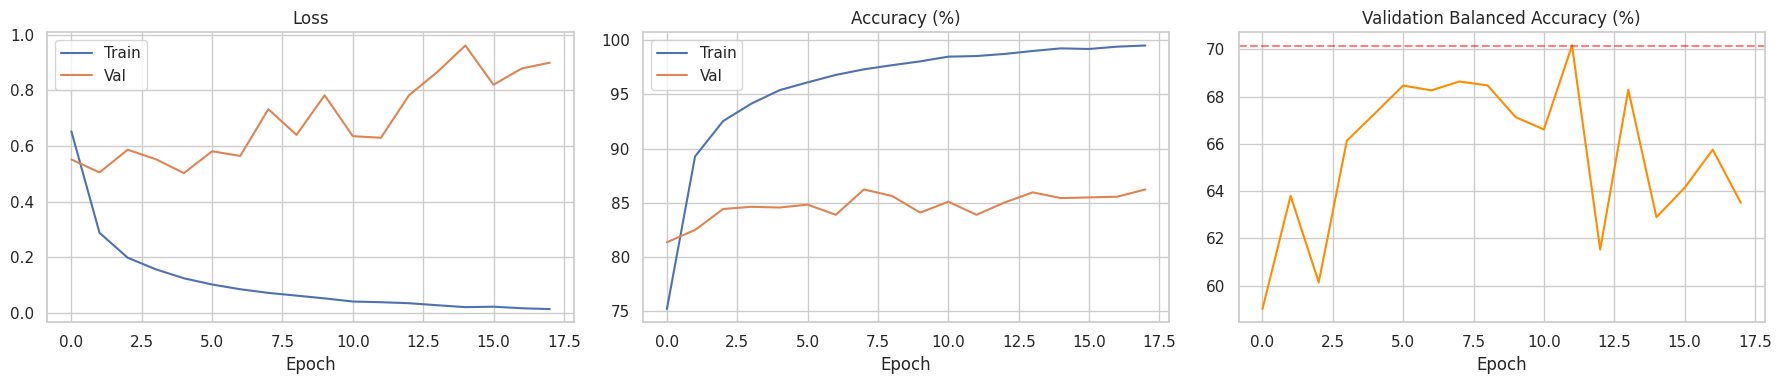

In [16]:
# Cell 18 — Plot Training History

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(history['train_loss'], label='Train', linewidth=1.5)
axes[0].plot(history['val_loss'],   label='Val',   linewidth=1.5)
axes[0].set_title('Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(history['train_acc'], label='Train', linewidth=1.5)
axes[1].plot(history['val_acc'],   label='Val',   linewidth=1.5)
axes[1].set_title('Accuracy (%)'); axes[1].legend(); axes[1].set_xlabel('Epoch')

axes[2].plot(history['val_bal_acc'], color='darkorange', linewidth=1.5)
axes[2].set_title('Validation Balanced Accuracy (%)'); axes[2].set_xlabel('Epoch')
axes[2].axhline(y=max(history['val_bal_acc']), color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [17]:
# Cell 19 — Final Evaluation on Validation Set

CLASS_NAMES = ['nv', 'mel', 'bkl', 'bcc', 'akiec', 'vasc', 'df']

# Load best checkpoint
model.load_state_dict(torch.load(CKPT_PATH))
_, final_acc, final_bal_acc, final_preds, final_labels = validate(
    model, val_loader, criterion
)

print(f"Final Val Accuracy        : {final_acc:.2f}%")
print(f"Final Balanced Accuracy   : {final_bal_acc:.2f}%")
print(f"\nClassification Report:\n")
print(classification_report(final_labels, final_preds, target_names=CLASS_NAMES))

  Val  :   0%|          | 0/24 [00:00<?, ?it/s]

Final Val Accuracy        : 83.87%
Final Balanced Accuracy   : 70.16%

Classification Report:

              precision    recall  f1-score   support

          nv       0.95      0.92      0.93      1080
         mel       0.44      0.64      0.52       123
         bkl       0.71      0.59      0.64       145
         bcc       0.68      0.75      0.72        65
       akiec       0.54      0.48      0.51        46
        vasc       0.67      0.80      0.73        20
          df       0.65      0.73      0.69        15

    accuracy                           0.84      1494
   macro avg       0.66      0.70      0.68      1494
weighted avg       0.85      0.84      0.84      1494



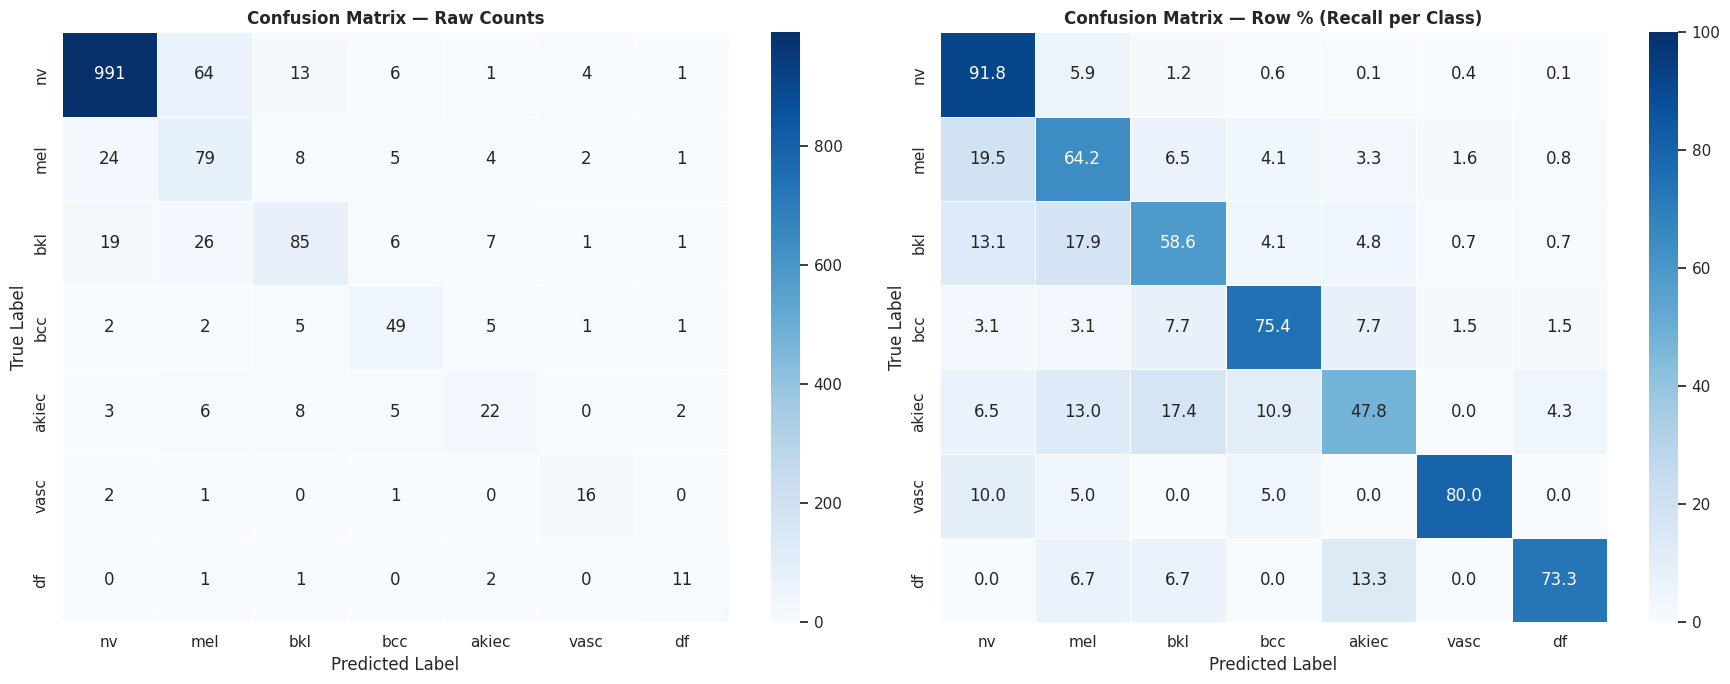

In [18]:
# Cell 20 — Confusion Matrix

cm = confusion_matrix(final_labels, final_preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            cmap='Blues', ax=axes[0], linewidths=0.5)
axes[0].set_title('Confusion Matrix — Raw Counts', fontweight='bold')
axes[0].set_ylabel('True Label'); axes[0].set_xlabel('Predicted Label')

# Row-normalised (recall per class)
sns.heatmap(cm_pct, annot=True, fmt='.1f',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            cmap='Blues', ax=axes[1], vmin=0, vmax=100, linewidths=0.5)
axes[1].set_title('Confusion Matrix — Row % (Recall per Class)', fontweight='bold')
axes[1].set_ylabel('True Label'); axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

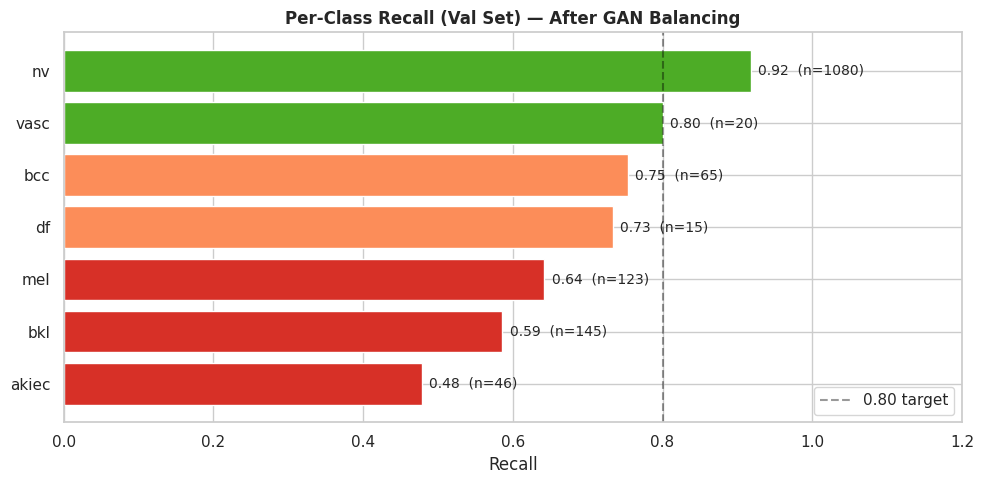

In [19]:
# Cell 21 — Per-Class Recall Bar Chart
from sklearn.metrics import recall_score

recalls = recall_score(final_labels, final_preds, average=None)
recall_df = pd.DataFrame({
    'Class': CLASS_NAMES,
    'Recall': recalls,
    'N_samples': [sum(l == i for l in final_labels) for i in range(NUM_CLASSES)]
})
recall_df = recall_df.sort_values('Recall')

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#d73027' if r < 0.70 else '#fc8d59' if r < 0.80 else '#4dac26'
          for r in recall_df['Recall']]
bars = ax.barh(recall_df['Class'], recall_df['Recall'], color=colors)

for bar, val, n in zip(bars, recall_df['Recall'], recall_df['N_samples']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}  (n={n})', va='center', fontsize=10)

ax.set_xlim(0, 1.2)
ax.axvline(x=0.80, color='black', linestyle='--', alpha=0.4, label='0.80 target')
ax.set_title('Per-Class Recall (Val Set) — After GAN Balancing', fontweight='bold')
ax.set_xlabel('Recall')
ax.legend()
plt.tight_layout()
plt.show()

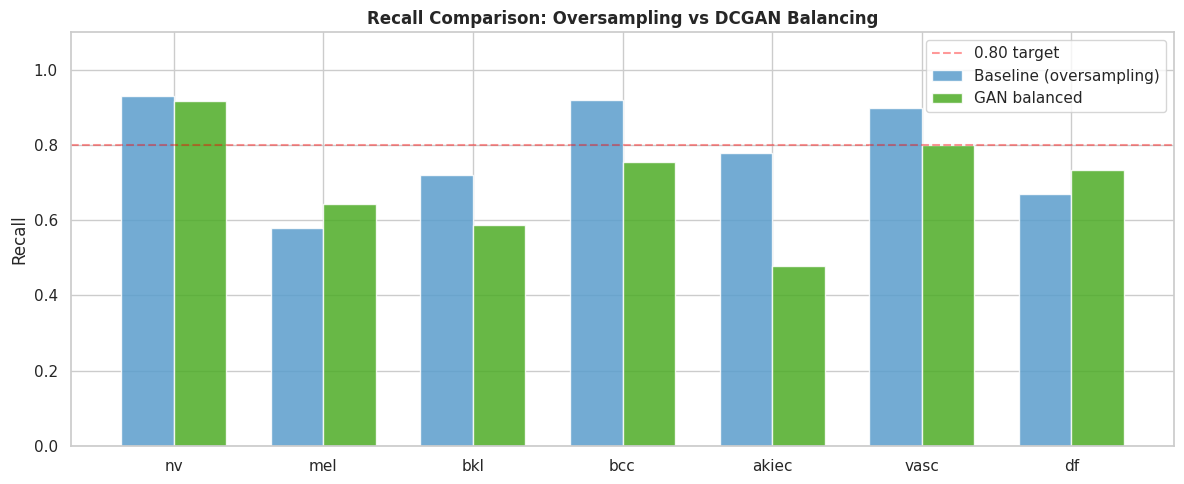


Baseline balanced acc : 0.7855
GAN balanced acc       : 0.7016
Delta                  : +-0.0839


In [20]:
# Cell 22 — Compare Baseline vs GAN Results

baseline = {
    'nv': 0.93, 'mel': 0.58, 'bkl': 0.72,
    'bcc': 0.92, 'akiec': 0.78, 'vasc': 0.90, 'df': 0.67
}
gan_recalls = dict(zip(CLASS_NAMES, recalls))

compare_df = pd.DataFrame({
    'Class': CLASS_NAMES,
    'Baseline (oversample)': [baseline[c] for c in CLASS_NAMES],
    'GAN balanced':          [gan_recalls[c] for c in CLASS_NAMES]
})

x = np.arange(len(CLASS_NAMES))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, compare_df['Baseline (oversample)'],
       width, label='Baseline (oversampling)', color='#5a9dcc', alpha=0.85)
ax.bar(x + width/2, compare_df['GAN balanced'],
       width, label='GAN balanced', color='#4dac26', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES)
ax.set_ylabel('Recall')
ax.set_ylim(0, 1.1)
ax.axhline(y=0.80, color='red', linestyle='--', alpha=0.4, label='0.80 target')
ax.legend()
ax.set_title('Recall Comparison: Oversampling vs DCGAN Balancing', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nBaseline balanced acc : 0.7855")
print(f"GAN balanced acc       : {final_bal_acc/100:.4f}")
print(f"Delta                  : +{(final_bal_acc/100 - 0.7855):.4f}")

In [21]:
!zip -r convnext_base_acgan_30_epochs.zip convnext_base_acgan_30_epochs.pth

  adding: convnext_base_acgan_30_epochs.pth (deflated 7%)


In [ ]:
from IPython.display import FileLink
FileLink(r'convnext_base_acgan_30_epochs.zip')